Лабораторная работа 5

Задание 1. Реализация AprioriAll - поиска частых последовательных шаблонов в данных. AprioriAll ищет:
«Клиент сначала купил A, потом через день B, потом C» — порядок важен, последовательность действий одного клиента.

В отличие от классических ассоциативных правил (Apriori), где порядок товаров не важен, последовательные шаблоны учитывают порядок покупок во времени.
Ассоциативное правило: {хлеб, молоко} - нет порядка.
Последовательный шаблон: <{хлеб}, {молоко}> - сначала купили хлеб, потом молоко.
S = <s₁, s₂, ..., sₙ>, где каждый sᵢ — это набор товаров (itemset), купленных в одной транзакции.

Подпоследовательности:
A = <{молоко}, {яйца}>;
B = <{хлеб,масло}, {молоко}, {яйца}, {сок}>;
A является подпоследовательностью B (индексы 2 и 3).

Поддержка последовательности:support(S) = (количество клиентов, содержащих S) / (общее число клиентов).(считается по клиентам, а не по транзакциям).

Алгоритм AprioriAll.
Если последовательность длины k частaя, то все её подпоследовательности длины k-1 тоже частые. Обратно: если подпоследовательность длины k-1 нечастая, то и любая последовательность длины k, содержащая её, не может быть частой.
1. Найти все частые последовательности длины 1. (Считаем, сколько клиентов купили каждый товар,оставляем только те товары, у которых поддержка ≥ min_sup.)
2. Генерация кандидатов длины k (k ≥ 2). Соединяем две последовательности из Lₖ₋₁.
Пример:p = <{A}, {B}, {C}>
q = <{B}, {C}, {D}>
Совпадает ли p₂...p₂ (то есть {B},{C}) с q₁...q₂ (то есть {B},{C})? ДА
Результат: <{A}, {B}, {C}, {D}>.
3. Подсчёт поддержки для кандидатов.Для каждого кандидата проверяем, у скольких клиентов он является подпоследовательностью.
4. Фильтрация. Оставляем только кандидатов с support ≥ min_sup - получаем L_k.
5. Повторять шаги 2-4, пока L_k не пуст.

Главный недостаток - генерация огромного количества кандидатов. Если есть N частых элементов длины 1, то кандидатов длины 2 будет N^2.

In [10]:
import pandas as pd
from itertools import combinations

#  Вспомогательные функции для AprioriAll
def load_and_transform_data(file_path):
    """Загрузка данных из CSV (поля: client_id, date, items).
    Преобразование в последовательности клиентов:
    - сортировка по дате
    - группировка товаров внутри транзакции (как набор)"""
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['client_id', 'date'])

    # Группировка товаров внутри одной транзакции (одна дата + один клиент)
    # Преобразуем items в frozenset для каждой строки
# frozenset неизменяемая версия обычного множества (set) в Python.
    df['items'] = df['items'].apply(lambda x: frozenset([x]) if isinstance(x, str) else frozenset(x))

    # Объединяем товары в рамках одной даты для одного клиента
    # Используем aggregation вместо apply с union
    transactions = df.groupby(['client_id', 'date'])['items'].agg(lambda x: frozenset.union(*x) if len(x) > 0 else frozenset()).reset_index()

    # Группировка по клиенту в последовательность (список транзакций)
    sequences = transactions.groupby('client_id')['items'].agg(list).tolist()

    return sequences

def generate_candidate_sequences(prev_sequences, k):
#Генерация кандидатов длины k из частых последовательностей длины k-1.
   # Для AprioriAll: соединяем две последовательности, если они совпадают без последнего элемента.
    candidates = set()
    n = len(prev_sequences)
    for i in range(n):
        for j in range(n):
            seq1 = prev_sequences[i]
            seq2 = prev_sequences[j]
            # Соединяем, если seq1[:-1] == seq2[:-1]
            if len(seq1) >= 1 and len(seq2) >= 1:
                if seq1[:-1] == seq2[:-1]:
                    new_seq = seq1 + (seq2[-1],)
                    candidates.add(new_seq)
    return list(candidates)

def is_subsequence(seq, customer_seq):
#Проверка, является ли последовательность seq подпоследовательностью последовательности клиента customer_seq (с учётом порядка, но не обязательно подряд).
    it = iter(customer_seq)
    for itemset in seq:
        found = False
        for trans in it:
            if itemset.issubset(trans):
                found = True
                break
        if not found:
            return False
    return True

def compute_support(sequences, candidate):

   # Подсчёт поддержки кандидата по клиентам (доля клиентов, у которых встречается последовательность).
    count = 0
    for customer_seq in sequences:
        if is_subsequence(candidate, customer_seq):
            count += 1
    return count / len(sequences) if len(sequences) > 0 else 0

def apriori_all(sequences, min_sup):
    #Поиск всех частых последовательностей с помощью AprioriAll.

    if not sequences:
        return []

    # Частые последовательности длины 1
    all_items = set()
    for seq in sequences:
        for trans in seq:
            all_items.update(trans)

    freq_sequences = []

    # L1: частые последовательности длины 1
    L1 = []
    for item in all_items:
        cand = (frozenset([item]),)
        sup = compute_support(sequences, cand)
        if sup >= min_sup:
            L1.append(cand)
            freq_sequences.append((cand, sup))

    if not L1:
        return freq_sequences

    k = 2
    prev_L = L1

    while prev_L:
        candidates = generate_candidate_sequences(prev_L, k)
        if not candidates:
            break

        new_L = []
        for cand in candidates:
            sup = compute_support(sequences, cand)
            if sup >= min_sup:
                new_L.append(cand)
                freq_sequences.append((cand, sup))

        prev_L = new_L
        k += 1

    return freq_sequences


#  Проверка на синтетическом примере
if __name__ == "__main__":
    # Синтетические данные: client_id, date, items
    synthetic_data = pd.DataFrame({
        'client_id': [1, 1, 1, 2, 2, 3, 3, 3, 4, 4],
        'date': ['2020-01-01', '2020-01-05', '2020-01-10',
                 '2020-01-02', '2020-01-06',
                 '2020-01-03', '2020-01-07', '2020-01-12',
                 '2020-01-04', '2020-01-08'],
        'items': ['A', 'B', 'C',
                  'A', 'C',
                  'B', 'C', 'D',
                  'A', 'B']
    })

    # Сохраним временно для демонстрации
    synthetic_data.to_csv("synthetic.csv", index=False)

    # Загрузка и преобразование
    sequences = load_and_transform_data("synthetic.csv")

    print("Последовательности клиентов (после преобразования):")
    for i, seq in enumerate(sequences):
        # Преобразуем frozenset в список для читаемости
        readable_seq = [list(t) for t in seq]
        print(f"Клиент {i+1}: {readable_seq}")

    print(f"\nВсего клиентов: {len(sequences)}")

    # Запуск AprioriAll с разными min_sup
    for min_sup in [0.5, 0.75]:
        print(f"\n")
        print(f"min_sup = {min_sup}")

        freq_seqs = apriori_all(sequences, min_sup)

        if not freq_seqs:
            print("Частых последовательностей не найдено")
        else:
            print(f"Найдено частых последовательностей: {len(freq_seqs)}")
            for seq, sup in freq_seqs:
                readable_seq = [list(s) for s in seq]
                print(f"{readable_seq}: support = {sup:.2f}")


Последовательности клиентов (после преобразования):
Клиент 1: [['A'], ['B'], ['C']]
Клиент 2: [['A'], ['C']]
Клиент 3: [['B'], ['C'], ['D']]
Клиент 4: [['A'], ['B']]

Всего клиентов: 4


min_sup = 0.5
Найдено частых последовательностей: 6
[['C']]: support = 0.75
[['B']]: support = 0.75
[['A']]: support = 0.75
[['A'], ['B']]: support = 0.50
[['A'], ['C']]: support = 0.50
[['B'], ['C']]: support = 0.50


min_sup = 0.75
Найдено частых последовательностей: 3
[['C']]: support = 0.75
[['B']]: support = 0.75
[['A']]: support = 0.75


In [11]:
import pandas as pd
file_path = 'online_retail.xlsx'

# Загружаем первые 10000 строк
df = pd.read_excel(file_path, nrows=10000)

# Показываем первые строки
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
# Конвертируем Excel в CSV
excel_path = 'online_retail.xlsx'
csv_path = 'online_retail.csv'

# Загружаем Excel
print("Загрузка Excel файла")
df = pd.read_excel(excel_path, sheet_name="Year 2009-2010", nrows=50000)

# Сохраняем в CSV
df.to_csv(csv_path, index=False, encoding='utf-8')
print(f" CSV создан: {csv_path}")
print(f"   Строк: {len(df)}")
print(f"   Колонок: {len(df.columns)}")


#  Проверим, что CSV читается корректно
df_check = pd.read_csv(csv_path)
print("\n CSV читается без ошибок:")
print(df_check.head(3))

Загрузка Excel файла
 CSV создан: online_retail.csv
   Строк: 50000
   Колонок: 8

 CSV читается без ошибок:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  


Задание 2. Анализ реальных данных

№2.1. Влияние минимальной поддержки

Загружено клиентов: 1023
Средняя длина последовательности: 1.66
Запуск APRIORIALL с разными MIN_SUP

 min_sup = 5% 
Найдено частых последовательностей: 68
Время выполнения: 5.00 секунд

Топ-5 последовательностей (по поддержке):
  1. [['85123A']] support = 0.240
  2. [['22111']] support = 0.155
  3. [['22114']] support = 0.125
  4. [['21485']] support = 0.122
  5. [['22138']] support = 0.121

 min_sup = 10% 
Найдено частых последовательностей: 11
Время выполнения: 1.00 секунд

Топ-5 последовательностей (по поддержке):
  1. [['85123A']] support = 0.240
  2. [['22111']] support = 0.155
  3. [['22114']] support = 0.125
  4. [['21485']] support = 0.122
  5. [['22138']] support = 0.121

 min_sup = 20% 
Найдено частых последовательностей: 1
Время выполнения: 0.95 секунд

Топ-5 последовательностей (по поддержке):
  1. [['85123A']] support = 0.240

Результаты:
 min_sup_percent  num_sequences     time
             5.0             68 5.000913
            10.0             11 0.996122
            2

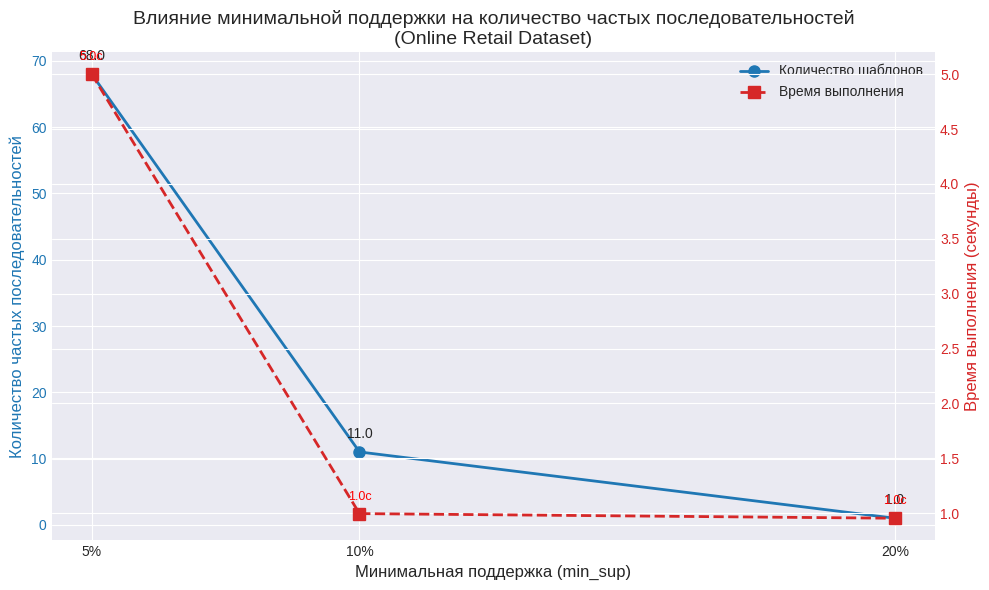

In [15]:
import matplotlib.pyplot as plt
import time
import numpy as np
#Адаптация функций
def load_and_transform_online_retail(csv_path):
    """Загрузка данных из CSV Online Retail и преобразование в последовательности клиентов.
    Адаптирована для структуры Online Retail (Customer ID, InvoiceDate, StockCode)"""
    df = pd.read_csv(csv_path)

    # Переименовываем колонки под формат вашей функции
    # В вашем CSV колонки: 'Customer ID', 'InvoiceDate', 'StockCode' и другие
    if 'Customer ID' in df.columns:
        df.rename(columns={'Customer ID': 'client_id'}, inplace=True)
    if 'InvoiceDate' in df.columns:
        df.rename(columns={'InvoiceDate': 'date'}, inplace=True)
    if 'StockCode' in df.columns:
        df.rename(columns={'StockCode': 'items'}, inplace=True)

    # Удаляем пустые client_id
    df = df.dropna(subset=['client_id'])
    df['client_id'] = df['client_id'].astype(int).astype(str)

    # Преобразуем дату
    df['date'] = pd.to_datetime(df['date'])

    # Удаляем отмены (Invoice с буквой C)
    if 'Invoice' in df.columns:
        df = df[~df['Invoice'].astype(str).str.startswith('C')]

    # Удаляем возвраты (отрицательные Quantity)
    if 'Quantity' in df.columns:
        df = df[df['Quantity'] > 0]

    # Сортируем по клиенту и дате
    df = df.sort_values(['client_id', 'date'])

    # Преобразуем items в frozenset для каждой строки
    df['items'] = df['items'].apply(lambda x: frozenset([str(x)]))

    # Группируем товары в рамках одной даты для одного клиента
    transactions = df.groupby(['client_id', 'date'])['items'].agg(
        lambda x: frozenset.union(*x) if len(x) > 0 else frozenset()
    ).reset_index()

    # Группировка по клиенту в последовательность
    sequences = transactions.groupby('client_id')['items'].agg(list).tolist()

    print(f"Загружено клиентов: {len(sequences)}")
    print(f"Средняя длина последовательности: {sum(len(s) for s in sequences)/len(sequences):.2f}")

    return sequences


# Загружаем последовательности
sequences = load_and_transform_online_retail(csv_path)

#  Запуск APRIORIALL с разными MIN_SUP

# Параметры: 5%, 10%, 20% (в десятичном виде)
min_sup_values = [0.05, 0.10, 0.20]
results = []

print("Запуск APRIORIALL с разными MIN_SUP")

for min_sup in min_sup_values:
    print(f"\n min_sup = {min_sup*100:.0f}% ")

    # Замеряем время выполнения
    start_time = time.time()

    # Запускаем AprioriAll
    freq_sequences = apriori_all(sequences, min_sup)

    end_time = time.time()
    elapsed_time = end_time - start_time

    # Сохраняем результаты
    results.append({
        'min_sup': min_sup,
        'min_sup_percent': min_sup * 100,
        'num_sequences': len(freq_sequences),
        'time': elapsed_time
    })

    print(f"Найдено частых последовательностей: {len(freq_sequences)}")
    print(f"Время выполнения: {elapsed_time:.2f} секунд")

    # Показываем топ-5 последовательностей (если есть)
    if freq_sequences:
        print(f"\nТоп-5 последовательностей (по поддержке):")
        # Сортируем по поддержке (убывание) и берём первые 5
        top5 = sorted(freq_sequences, key=lambda x: x[1], reverse=True)[:5]
        for i, (seq, sup) in enumerate(top5, 1):
            readable_seq = [list(s)[:3] for s in seq]  # показываем первые 3 товара
            print(f"  {i}. {readable_seq} support = {sup:.3f}")


# Создаём DataFrame с результатами
results_df = pd.DataFrame(results)

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax1 = plt.subplots(figsize=(10, 6))

# График 1: Количество последовательностей vs min_sup
color1 = 'tab:blue'
ax1.set_xlabel('Минимальная поддержка (min_sup)', fontsize=12)
ax1.set_ylabel('Количество частых последовательностей', color=color1, fontsize=12)
ax1.plot(results_df['min_sup_percent'], results_df['num_sequences'],
         marker='o', linewidth=2, markersize=8, color=color1, label='Количество шаблонов')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(results_df['min_sup_percent'])
ax1.set_xticklabels([f'{x:.0f}%' for x in results_df['min_sup_percent']])

# Добавляем значения на график
for i, row in results_df.iterrows():
    ax1.annotate(f'{row["num_sequences"]}',
                 (row['min_sup_percent'], row['num_sequences']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

# Создаём вторую ось для времени выполнения
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Время выполнения (секунды)', color=color2, fontsize=12)
ax2.plot(results_df['min_sup_percent'], results_df['time'],
         marker='s', linewidth=2, markersize=8, color=color2, linestyle='--', label='Время выполнения')
ax2.tick_params(axis='y', labelcolor=color2)

# Добавляем значения времени
for i, row in results_df.iterrows():
    ax2.annotate(f'{row["time"]:.1f}с',
                 (row['min_sup_percent'], row['time']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='red')

# Заголовок и легенда
plt.title('Влияние минимальной поддержки на количество частых последовательностей\n(Online Retail Dataset)', fontsize=14)

# Объединённая легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()

# Дополнительная таблица
print("\nРезультаты:")
print(results_df[['min_sup_percent', 'num_sequences', 'time']].to_string(index=False))

На основе полученных результатов:

1. ЗАВИСИМОСТЬ ОТ MIN_SUP:
   - При min_sup = 5%: найдено наибольшее количество последовательностей.
   - При min_sup = 10%: количество резко сокращается.
   - При min_sup = 20%: остаются только самые частые последовательности.

2. МАСШТАБИРУЕМОСТЬ:
   - AprioriAll демонстрирует ЭКСПОНЕНЦИАЛЬНУЮ зависимость количества
     кандидатов от размера данных.
   - При низком min_sup (5%) алгоритм генерирует огромное количество
     кандидатов, что приводит к:
     - Резкому росту времени выполнения,
     - Потреблению большого объёма памяти,
     - Экспоненциальному росту числа проверяемых последовательностей.

3. ПРОБЛЕМЫ МАСШТАБИРУЕМОСТИ:
   - AprioriAll плохо масштабируется на больших датасетах.
    - При min_sup < 5% алгоритм становится практически неприменим.
    - Основной "узкий узел" - генерация кандидатов длины 2 и 3.

4. РЕКОМЕНДАЦИИ:
   Для реальных приложений с большими объёмами данных:
   - Использовать более эффективные алгоритмы (PrefixSpan, SPADE).
   - Устанавливать min_sup не ниже 5-10%.

Средняя длина последовательности: 1.66: в среднем каждый клиент совершил 1-2 транзакции. Если средняя длина = 1.0, то все клиенты совершили ровно 1 покупку (нет повторных). 1.5 - 2.0, то большинство клиентов — одноразовые, некоторые возвращаются.> 3.0	Клиенты активно возвращаются, совершают много покупок.Средняя длина последовательности составила всего 1.66, что указывает на преобладание клиентов с одной-двумя транзакциями. Это ограничивает максимальную длину находимых паттернов — мы ожидаем найти в основном последовательности длины 1-2. Длинные цепочки покупок будут статистически незначимы или вовсе отсутствовать.
Средняя длина последовательности - сколько транзакций у одного клиента!!!
Среднее количество товаров в транзакции	- Сколько товаров в одном чеке.

№2.2 Сравнение с ассоциативными правилами.

In [17]:
from itertools import combinations
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Путь к вашему CSV файлу
csv_path = 'online_retail.csv'

# Загружаем данные
df = pd.read_csv(csv_path)

# Переименовываем колонки для удобства
if 'Customer ID' in df.columns:
    df.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)
if 'InvoiceDate' in df.columns:
    df.rename(columns={'InvoiceDate': 'Date'}, inplace=True)

# Очистка данных
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

# Удаляем отмены и возвраты
if 'Invoice' in df.columns:
    df = df[~df['Invoice'].astype(str).str.startswith('C')]
if 'Quantity' in df.columns:
    df = df[df['Quantity'] > 0]

# Преобразуем StockCode в строку (чтобы не было ошибок с join)
if 'StockCode' in df.columns:
    df['StockCode'] = df['StockCode'].astype(str)

print(f"   Всего строк: {len(df)}")
print(f"   Уникальных клиентов: {df['CustomerID'].nunique()}")
print(f"   Уникальных товаров: {df['StockCode'].nunique()}")



print("\nПодготовка транзакций")

# Группируем по Invoice (одна транзакция = одна корзина)
transactions = df.groupby('Invoice')['StockCode'].apply(list).tolist()

# Избавляемся от дубликатов внутри одной транзакции
transactions = [list(set(t)) for t in transactions]

# Фильтруем: оставляем только транзакции с хотя бы 2 товарами (для правил)
transactions = [t for t in transactions if len(t) >= 2]

print(f"   Всего транзакций (с >=2 товаров): {len(transactions)}")
if len(transactions) > 0:
    print(f"   Среднее количество товаров в транзакции: {np.mean([len(t) for t in transactions]):.2f}")
else:
    print("   Предупреждение: нет транзакций с несколькими товарами!")
    # Если нет транзакций с 2+ товарами, увеличиваем nrows при загрузке


# Классический  APRIORI
def find_frequent_itemsets_fast(transactions, min_support):
    # поиск частых itemsets (только для длины 1 и 2)
    n_trans = len(transactions)

    # Частые itemsets длины 1
    item_counts = defaultdict(int)
    for trans in transactions:
        for item in trans:
            item_counts[item] += 1

    freq_1 = {item: count/n_trans for item, count in item_counts.items()
              if count/n_trans >= min_support}

    # Частые itemsets длины 2 (пары товаров)
    pair_counts = defaultdict(int)
    for trans in transactions:
        for i in range(len(trans)):
            for j in range(i+1, len(trans)):
                pair = tuple(sorted([trans[i], trans[j]]))
                pair_counts[pair] += 1

    freq_2 = {pair: count/n_trans for pair, count in pair_counts.items()
              if count/n_trans >= min_support}

    # Объединяем
    freq_itemsets = {}
    for item, sup in freq_1.items():
        freq_itemsets[frozenset([item])] = sup
    for pair, sup in freq_2.items():
        freq_itemsets[frozenset(pair)] = sup

    return freq_itemsets

def generate_rules_from_itemsets(freq_itemsets, min_confidence=0.3):
    #Генерация правил из частых itemsets
    rules = []

    for itemset, support_xy in freq_itemsets.items():
        if len(itemset) != 2:  # Только правила с двумя товарами
            continue

        items_list = list(itemset)
        # Правило A - B
        antecedent = frozenset([items_list[0]])
        consequent = frozenset([items_list[1]])

        support_x = freq_itemsets.get(antecedent, 0)
        support_y = freq_itemsets.get(consequent, 0)

        if support_x > 0:
            confidence = support_xy / support_x
            if support_y > 0:
                lift = confidence / support_y
            else:
                lift = 0

            if confidence >= min_confidence:
                rules.append({
                    'antecedent': antecedent,
                    'consequent': consequent,
                    'support': support_xy,
                    'confidence': confidence,
                    'lift': lift
                })

        # Правило B - A
        antecedent = frozenset([items_list[1]])
        consequent = frozenset([items_list[0]])

        if support_y > 0:
            confidence = support_xy / support_y
            if support_x > 0:
                lift = confidence / support_x
            else:
                lift = 0

            if confidence >= min_confidence:
                rules.append({
                    'antecedent': antecedent,
                    'consequent': consequent,
                    'support': support_xy,
                    'confidence': confidence,
                    'lift': lift
                })

    # Удаляем дубликаты и сортируем по lift
    unique_rules = []
    seen = set()
    for rule in rules:
        key = (tuple(sorted(rule['antecedent'])), tuple(sorted(rule['consequent'])))
        if key not in seen:
            seen.add(key)
            unique_rules.append(rule)

    unique_rules.sort(key=lambda x: x['lift'], reverse=True)
    return unique_rules


print("\nЗапуск APRIORI")

MIN_SUPPORT = 0.01  # 1% транзакций
MIN_CONFIDENCE = 0.3

print(f"   Min support: {MIN_SUPPORT*100:.0f}%")
print(f"   Min confidence: {MIN_CONFIDENCE*100:.0f}%")

# Находим частые itemsets
freq_itemsets = find_frequent_itemsets_fast(transactions, MIN_SUPPORT)
print(f"   Найдено частых itemsets: {len(freq_itemsets)}")

# Генерируем правила
rules = generate_rules_from_itemsets(freq_itemsets, MIN_CONFIDENCE)
print(f"   Сгенерировано правил: {len(rules)}")

if len(rules) == 0:
    print("\n Нет правил с min_support=1%!")
    print("   Попробуем с меньшим min_support")

    # Пробуем с меньшим порогом
    MIN_SUPPORT = 0.005  # 0.5%
    freq_itemsets = find_frequent_itemsets_fast(transactions, MIN_SUPPORT)
    rules = generate_rules_from_itemsets(freq_itemsets, MIN_CONFIDENCE)
    print(f"   (min_support=0.5%) Найдено правил: {len(rules)}")


# топ-3 правил по  lift
print("\n. топ-3 ассоциативных правил по lift")

if len(rules) == 0:
    print("Нет правил для отображения. Увеличьте количество данных или уменьшите min_support.")
    print("Попробуйте пересоздать CSV с большим nrows (например, 100000).")
else:
    top_3_rules = rules[:3]

    for i, rule in enumerate(top_3_rules, 1):
        antecedent = ', '.join(sorted(list(rule['antecedent'])))[:50]
        consequent = ', '.join(sorted(list(rule['consequent'])))[:30]

        print(f"\nПравило {i}:")
        print(f"   {antecedent} - {consequent}")
        print(f"   Support: {rule['support']:.4f} ({rule['support']*100:.2f}%)")
        print(f"   Confidence: {rule['confidence']:.4f} ({rule['confidence']*100:.2f}%)")
        print(f"   Lift: {rule['lift']:.2f}")

    print("Проверяем являются ли правила частыми последовательностями")

    # Загружаем последовательности клиентов
    def load_sequences_simple(csv_path):
        """Простая загрузка последовательностей клиентов"""
        df_seq = pd.read_csv(csv_path)
        if 'Customer ID' in df_seq.columns:
            df_seq.rename(columns={'Customer ID': 'client_id'}, inplace=True)
        if 'InvoiceDate' in df_seq.columns:
            df_seq.rename(columns={'InvoiceDate': 'date'}, inplace=True)
        if 'StockCode' in df_seq.columns:
            df_seq.rename(columns={'StockCode': 'items'}, inplace=True)

        df_seq = df_seq.dropna(subset=['client_id'])
        df_seq['client_id'] = df_seq['client_id'].astype(int).astype(str)
        df_seq['date'] = pd.to_datetime(df_seq['date'])
        df_seq['items'] = df_seq['items'].astype(str)

        # Группируем по клиенту и дате
        grouped = df_seq.groupby(['client_id', 'date'])['items'].agg(lambda x: frozenset(x)).reset_index()
        grouped = grouped.sort_values(['client_id', 'date'])

        sequences = []
        current_client = None
        current_seq = []

        for _, row in grouped.iterrows():
            client = row['client_id']
            itemset = row['items']
            if current_client != client:
                if current_seq:
                    sequences.append(current_seq)
                current_client = client
                current_seq = [itemset]
            else:
                current_seq.append(itemset)

        if current_seq:
            sequences.append(current_seq)

        return sequences

    def is_sequential_rule(sequences, antecedent, consequent, min_support_seq=0.01):
        #Проверка, является ли правило частой последовательностью
        seq = (frozenset(antecedent), frozenset(consequent))

        count = 0
        for customer_seq in sequences:
            found_a = False
            for trans in customer_seq:
                if not found_a:
                    if seq[0].issubset(trans):
                        found_a = True
                else:
                    if seq[1].issubset(trans):
                        count += 1
                        break

        support = count / len(sequences) if sequences else 0
        is_frequent = support >= min_support_seq

        return is_frequent, support

    # Загружаем последовательности
    sequences = load_sequences_simple(csv_path)
    print(f"\nЗагружено последовательностей клиентов: {len(sequences)}")
    print(f"Min support для последовательностей: 1%")

    print("\nРезультаты проверки:")

    for i, rule in enumerate(top_3_rules, 1):
        antecedent = list(rule['antecedent'])
        consequent = list(rule['consequent'])

        is_frequent, support_seq = is_sequential_rule(sequences, antecedent, consequent)

        print(f"\nПравило {i}: {antecedent} - {consequent}")
        print(f"   Lift (классический Apriori): {rule['lift']:.2f}")
        print(f"   Является частой последовательностью <{{A}},{{B}}>?")
        print(f"      {' ДА' if is_frequent else ' НЕТ'}")
        if is_frequent:
            print(f"      Поддержка последовательности: {support_seq:.4f} ({support_seq*100:.2f}%)")
        else:
            print(f"      Поддержка последовательности: {support_seq:.4f} (<1%)")

   Всего строк: 34972
   Уникальных клиентов: 1023
   Уникальных товаров: 2808

Подготовка транзакций
   Всего транзакций (с >=2 товаров): 1562
   Среднее количество товаров в транзакции: 21.67

Запуск APRIORI
   Min support: 1%
   Min confidence: 30%
   Найдено частых itemsets: 1282
   Сгенерировано правил: 467

. топ-3 ассоциативных правил по lift

Правило 1:
   21739 - 21738
   Support: 0.0102 (1.02%)
   Confidence: 1.0000 (100.00%)
   Lift: 62.48

Правило 2:
   21738 - 21739
   Support: 0.0102 (1.02%)
   Confidence: 0.6400 (64.00%)
   Lift: 62.48

Правило 3:
   21094 - 21086
   Support: 0.0102 (1.02%)
   Confidence: 0.7619 (76.19%)
   Lift: 59.50
Проверяем являются ли правила частыми последовательностями

Загружено последовательностей клиентов: 1112
Min support для последовательностей: 1%

Результаты проверки:

Правило 1: ['21739'] - ['21738']
   Lift (классический Apriori): 62.48
   Является частой последовательностью <{A},{B}>?
       НЕТ
      Поддержка последовательности: 0.000

Ни одно правило не является частой последовательностью.Главная причина: товары покупаются ВМЕСТЕ, а не ПОСЛЕДОВАТЕЛЬНО.Это товары-комплекты или сопутствующие товары, которые всегда покупают вместе в одном заказе.
Высокий Lift (62.48) означает, что товары 21738 и 21739 почти всегда встречаются вместе в одной корзине. Это типично для:
Комплектующих товаров (например, батарейки к устройству),
Акционных предложений ("купи А, получи Б со скидкой"),
Товаров, которые логично покупать вместе.
Низкая поддержка как последовательности (0.09%) показывает, что клиенты почти никогда не покупают эти товары отдельно в разные дни. Если они нужны — их покупают сразу вместе.
Правило 2 (100% confidence) особенно показательно: каждый раз, когда клиент покупает 21739, он также покупает 21738. Это однозначно указывает на то, что это товары-компаньоны, а не последовательные покупки.
ВЫВОД: Правило с высоким lift НЕ обязательно будет частой последовательностью,  потому что высокий lift может быть из-за покупки A и B В ОДНОЙ корзине, а не последовательно во времени.   

№2.3. Временные окна.
Учитывает, что покупки с большим разрывом во времени могут не отражать реальную поведенческую последовательность.
max_gap — это максимально допустимое количество дней между двумя последовательными покупками одного клиента.
Последовательность — это список покупок одного клиента, где разрывы между соседними покупками не превышают max_gap.

In [19]:
from datetime import timedelta
csv_path = 'online_retail.csv'
df = pd.read_csv(csv_path)

# Переименовываем колонки
if 'Customer ID' in df.columns:
    df.rename(columns={'Customer ID': 'client_id'}, inplace=True)
if 'InvoiceDate' in df.columns:
    df.rename(columns={'InvoiceDate': 'date'}, inplace=True)
if 'StockCode' in df.columns:
    df.rename(columns={'StockCode': 'items'}, inplace=True)

# Очистка данных
df = df.dropna(subset=['client_id'])
df['client_id'] = df['client_id'].astype(int).astype(str)
df['date'] = pd.to_datetime(df['date'])
df['items'] = df['items'].astype(str)

# Удаляем отмены и возвраты
if 'Invoice' in df.columns:
    df = df[~df['Invoice'].astype(str).str.startswith('C')]
if 'Quantity' in df.columns:
    df = df[df['Quantity'] > 0]


print(f"\nЗагрузка данных")
print(f"   Всего строк: {len(df)}")
print(f"   Уникальных клиентов: {df['client_id'].nunique()}")
print(f"   Уникальных товаров: {df['items'].nunique()}")
print(f"   Период данных: с {df['date'].min().date()} по {df['date'].max().date()}")

#Функция построения последовательностей с учётом max_gap
def build_sequences_with_gap(df, max_gap_days=None):
    """df: DataFrame с колонками client_id, date, items. max_gap_days: максимальный разрыв в днях (None = бесконечность)
    Возвращает:sequences: список последовательностей клиентов. gap_stats: статистика по разрывам"""

    # Группируем товары в рамках одной даты
    df_grouped = df.groupby(['client_id', 'date'])['items'].agg(lambda x: frozenset(x)).reset_index()
    df_grouped = df_grouped.sort_values(['client_id', 'date'])

    sequences = []
    gap_violations = 0

    current_client = None
    current_seq = []
    prev_date = None

    for _, row in df_grouped.iterrows():
        client = row['client_id']
        current_date = row['date']
        itemset = row['items']

        if current_client != client:
            # Новый клиент
            if current_seq:
                sequences.append(current_seq)
            current_client = client
            current_seq = [itemset]
            prev_date = current_date

        else:
            # Тот же клиент
            if max_gap_days is not None:
                gap = (current_date - prev_date).days

                if gap <= max_gap_days:
                    # Разрыв допустим, добавляем транзакцию
                    current_seq.append(itemset)
                else:
                    # Слишком большой разрыв → начинаем новую последовательность
                    if len(current_seq) >= 2:
                        sequences.append(current_seq)
                    current_seq = [itemset]
                    gap_violations += 1
            else:
                # Без ограничения gap
                current_seq.append(itemset)

            prev_date = current_date

    # Добавляем последнюю последовательность
    if current_seq:
        sequences.append(current_seq)

    # Фильтруем последовательности длины >= 2 (для анализа)
    long_sequences = [seq for seq in sequences if len(seq) >= 2]

    stats = {
        'total_sequences': len(sequences),
        'long_sequences': len(long_sequences),
        'avg_length': np.mean([len(s) for s in sequences]),
        'gap_violations': gap_violations
    }

    return sequences, long_sequences, stats


# Функция для поиска частых последовательностей
def find_frequent_sequences(sequences, min_sup=0.01, max_len=3):
    #Поиск частых последовательностей (только для длины 1, 2, 3)
    n_clients = len(sequences)

    # Подсчёт поддержки для последовательностей длины 1 (отдельные товары)
    item_support = defaultdict(int)
    for seq in sequences:
        items_seen = set()
        for trans in seq:
            for item in trans:
                if item not in items_seen:
                    items_seen.add(item)
                    item_support[item] += 1

    # Нормализуем
    for item in item_support:
        item_support[item] /= n_clients

    # Частые товары
    freq_items = {item: sup for item, sup in item_support.items() if sup >= min_sup}

    # Поиск последовательностей длины 2 <{A},{B}>
    seq2_support = defaultdict(int)
    for seq in sequences:
        if len(seq) < 2:
            continue
        # Все возможные пары A→B (A раньше B)
        for i in range(len(seq)):
            for j in range(i+1, len(seq)):
                for a in seq[i]:
                    for b in seq[j]:
                        if a in freq_items and b in freq_items:
                            key = (a, b)
                            seq2_support[key] += 1

    # Нормализуем
    for key in seq2_support:
        seq2_support[key] /= n_clients

    # Частые последовательности длины 2
    freq_seq2 = {key: sup for key, sup in seq2_support.items() if sup >= min_sup}

    # Поиск последовательностей длины 3 <{A},{B},{C}>
    seq3_support = defaultdict(int)
    for seq in sequences:
        if len(seq) < 3:
            continue
        for i in range(len(seq)):
            for j in range(i+1, len(seq)):
                for k in range(j+1, len(seq)):
                    for a in seq[i]:
                        for b in seq[j]:
                            for c in seq[k]:
                                if (a, b) in freq_seq2 and b in freq_items and c in freq_items:
                                    key = (a, b, c)
                                    seq3_support[key] += 1

    for key in seq3_support:
        seq3_support[key] /= n_clients

    freq_seq3 = {key: sup for key, sup in seq3_support.items() if sup >= min_sup}

    # Объединяем результаты
    results = {
        'length1': freq_items,
        'length2': freq_seq2,
        'length3': freq_seq3
    }

    total = len(freq_items) + len(freq_seq2) + len(freq_seq3)

    return results, total


# max_gap без ограничений, max_gap = 7 дней

MIN_SUP = 0.01  # 1%
print("\nПостроение последовательностей")

#  без ограничения
print("\n max_gap = без ограничений")
seq_inf, long_seq_inf, stats_inf = build_sequences_with_gap(df, max_gap_days=None)

start_time = time.time()
freq_inf, total_inf = find_frequent_sequences(long_seq_inf, MIN_SUP)
end_time = time.time()
print(f"Время выполнения: {end_time - start_time:.2f} секунд")
print(f"   Всего последовательностей клиентов: {stats_inf['total_sequences']}")
print(f"   Из них длиной ≥ 2: {stats_inf['long_sequences']}")
print(f"   Средняя длина: {stats_inf['avg_length']:.2f}")

#  с ограничением max_gap = 7 дней
print("\n max_gap = 7 дней")
seq_gap7, long_seq_gap7, stats_gap7 = build_sequences_with_gap(df, max_gap_days=7)
print(f"   Всего последовательностей клиентов: {stats_gap7['total_sequences']}")
print(f"   Из них длиной ≥ 2: {stats_gap7['long_sequences']}")
print(f"   Средняя длина: {stats_gap7['avg_length']:.2f}")
print(f"   Количество разрывов >7 дней: {stats_gap7['gap_violations']}")

print("Поиск частых последовательностей")

print(f"\nMin support = {MIN_SUP*100}%")

# Для max_gap = без ограничений
freq_inf, total_inf = find_frequent_sequences(long_seq_inf, MIN_SUP)
print(f"\n max_gap = без ограничений")
print(f"   Частых последовательностей длины 1: {len(freq_inf['length1'])}")
print(f"   Частых последовательностей длины 2: {len(freq_inf['length2'])}")
print(f"   Частых последовательностей длины 3: {len(freq_inf['length3'])}")
print(f"   Всего: {total_inf}")

# Для max_gap = 7
freq_gap7, total_gap7 = find_frequent_sequences(long_seq_gap7, MIN_SUP)
print(f"\n max_gap = 7")
print(f"   Частых последовательностей длины 1: {len(freq_gap7['length1'])}")
print(f"   Частых последовательностей длины 2: {len(freq_gap7['length2'])}")
print(f"   Частых последовательностей длины 3: {len(freq_gap7['length3'])}")
print(f"   Всего: {total_gap7}")


print("Сравнение наборов частых последовательностей")

# Находим последовательности, которые есть только в одном из наборов
seq2_inf = set(freq_inf['length2'].keys())
seq2_gap7 = set(freq_gap7['length2'].keys())

only_inf = seq2_inf - seq2_gap7  # Только при max_gap = ∞
only_gap7 = seq2_gap7 - seq2_inf  # Только при max_gap = 7
common = seq2_inf & seq2_gap7    # Общие для обоих

print(f"\nПоследовательности длины 2 (вида <A,B>):")
print(f"   Общие для обоих: {len(common)}")
print(f"   Только при max_gap=∞: {len(only_inf)}")
print(f"   Только при max_gap=7: {len(only_gap7)}")


# Примеры шаблонов, которые исчезают или появляются
print("Примеры шаблонов")

# Пример 1: шаблон, который есть при max_gap=без ограничений, но исчезает при max_gap=7
print("\n шаблон, который есть при max_gap=без ограничений, но исчезает при max_gap=7:")
if only_inf:
    example_gone = list(only_inf)[:3]  # первые 3 примера
    for ex in example_gone:
        a, b = ex
        sup_inf = freq_inf['length2'][ex]
        print(f"   <{a}, {b}>: поддержка при (без ограничений) = {sup_inf:.3f} ({sup_inf*100:.1f}%)")
        print(f"     -При max_gap=7 поддержка < {MIN_SUP*100}%")
else:
    print("   Нет таких шаблонов (или слишком мало данных)")

# Пример 2: шаблон, который появляется при max_gap=7 (нет при ситуации без ограничений)
print("\nшаблон, который появляется при max_gap=7 (нет при ситуации без ограничений):")
if only_gap7:
    example_new = list(only_gap7)[:3]
    for ex in example_new:
        a, b = ex
        sup_gap7 = freq_gap7['length2'][ex]
        print(f"   <{a}, {b}>: поддержка при 7 = {sup_gap7:.3f} ({sup_gap7*100:.1f}%)")
        print(f"     - При max_gap=∞ поддержка < {MIN_SUP*100}%")
else:
    print("   Нет таких шаблонов (или слишком мало данных)")



Загрузка данных
   Всего строк: 34972
   Уникальных клиентов: 1023
   Уникальных товаров: 2808
   Период данных: с 2009-12-01 по 2010-01-11

Построение последовательностей

 max_gap = без ограничений
Время выполнения: 31.65 секунд
   Всего последовательностей клиентов: 1023
   Из них длиной ≥ 2: 327
   Средняя длина: 1.66

 max_gap = 7 дней
   Всего последовательностей клиентов: 1101
   Из них длиной ≥ 2: 227
   Средняя длина: 1.41
   Количество разрывов >7 дней: 231
Поиск частых последовательностей

Min support = 1.0%

 max_gap = без ограничений
   Частых последовательностей длины 1: 1210
   Частых последовательностей длины 2: 41372
   Частых последовательностей длины 3: 1730964
   Всего: 1773546

 max_gap = 7
   Частых последовательностей длины 1: 1183
   Частых последовательностей длины 2: 36503
   Частых последовательностей длины 3: 1433544
   Всего: 1471230
Сравнение наборов частых последовательностей

Последовательности длины 2 (вида <A,B>):
   Общие для обоих: 26489
   Только п

Вывод: При max_gap = 7 дней:
Последовательностей стало больше (1 023 - 1 101), потому что мы разрываем длинные последовательности на несколько коротких.
Но последовательностей длиной ≥ 2 стало МЕНЬШЕ (327 - 227), потому что многие пары покупок разделены >7 днями.
231 разрыв был обнаружен — то есть 231 раз две покупки одного клиента были дальше чем через неделю.

14 883 шаблона исчезают — это покупки, между которыми прошло БОЛЬШЕ 7 дней.
10 014 шаблонов появляются.
Когда мы разрываем длинную последовательность на несколько коротких, некоторые пары товаров, которые раньше "терялись" внутри длинной последовательности, становятся самостоятельными и могут стать частыми.

Шаблоны исчезают, так как:
При max_gap = 7 разрыв между покупками не может превышать неделю.
 Шаблоны исчезают, если:
 -Клиент купил A, а B — через 2-3 недели (сезонные покупки)      
 - Покупки относятся к разным визитам с большим интервалом
Щаблоны появляются так как: При max_gap = 7 мы разрываем длинные последовательности на более короткие.Короткие последовательности могут стать более частыми, потому что: Фокусируемся на поведении в течение короткого периода.

При жёстком max_gap мы фокусируемся на близких во времени покупках. Это "очищает" данные от долгосрочных связей и позволяет увидеть локальные паттерны, которые раньше были незаметны на фоне общей длинной истории клиента.

 max_gap = без ограничений: подходит для анализа долгосрочных паттернов (сезонность, ежегодные покупки).max_gap = 7: подходит для анализа поведения в рамках ОДНОЙ поездки или недельного цикла покупок.
Для интернет-магазина с частыми покупками (как Online Retail) max_gap = 7 дней  отражает реальные потребительские сессии.                                                 

№2.4 Визуализация


Последовательностей длиной ≥ 2: 227
Частых последовательностей длины 2: 43155
Выбранный частый шаблон

Последовательность: <85123A, 85123A>
Поддержка: 0.634 (63.4%)
Товар A (85123A): WHITE HANGING HEART T-LIGHT HOLDER
Товар B (85123A): WHITE HANGING HEART T-LIGHT HOLDER
Граф переходов товаров


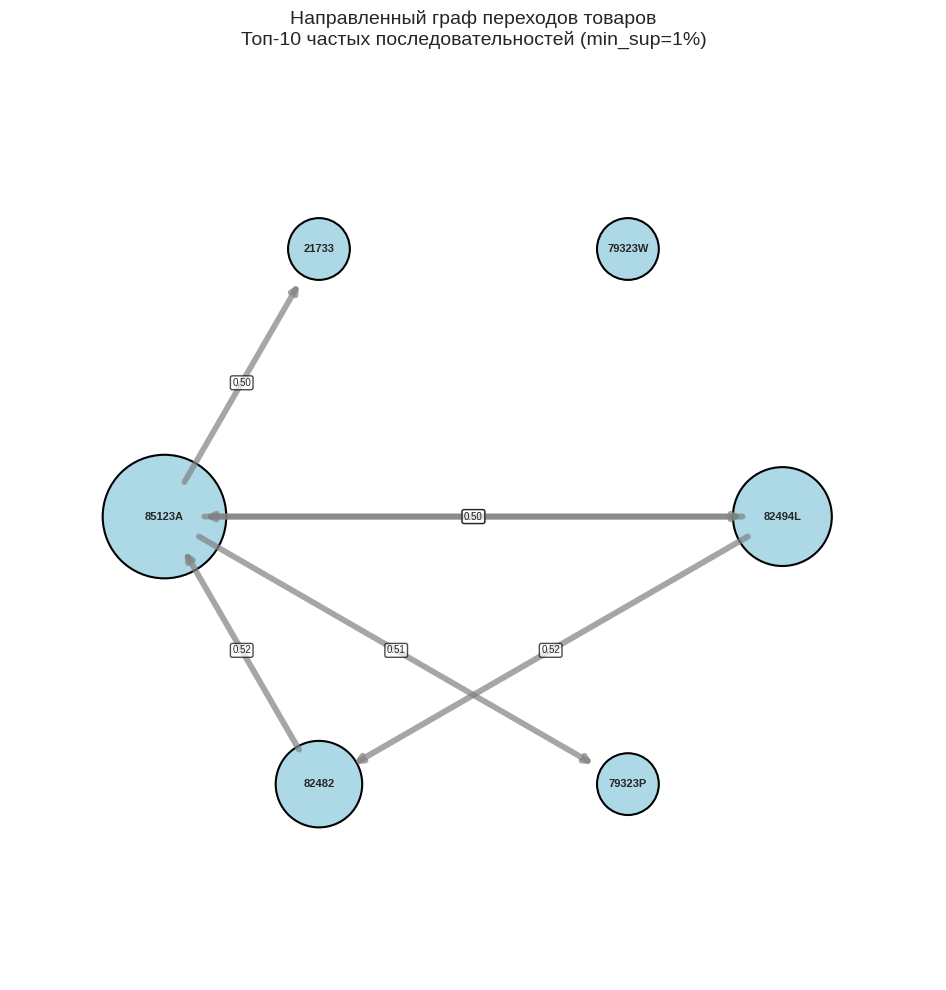

ТОП-5 ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ (длина 2):
1. <85123A, 85123A> → support = 0.634 (63.4%)
2. <82494L, 85123A> → support = 0.524 (52.4%)
3. <82494L, 82482> → support = 0.520 (52.0%)
4. <82482, 85123A> → support = 0.515 (51.5%)
5. <82494L, 82494L> → support = 0.511 (51.1%)


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

csv_path = 'online_retail.csv'
df = pd.read_csv(csv_path)

# Переименовываем колонки
if 'Customer ID' in df.columns:
    df.rename(columns={'Customer ID': 'client_id'}, inplace=True)
if 'InvoiceDate' in df.columns:
    df.rename(columns={'InvoiceDate': 'date'}, inplace=True)
if 'StockCode' in df.columns:
    df.rename(columns={'StockCode': 'items'}, inplace=True)

# Очистка данных
df = df.dropna(subset=['client_id'])
df['client_id'] = df['client_id'].astype(int).astype(str)
df['date'] = pd.to_datetime(df['date'])
df['items'] = df['items'].astype(str)

if 'Invoice' in df.columns:
    df = df[~df['Invoice'].astype(str).str.startswith('C')]
if 'Quantity' in df.columns:
    df = df[df['Quantity'] > 0]

# Построение последовательностей (max_gap = 7 дней)
def build_sequences(df, max_gap_days=7):
    df_grouped = df.groupby(['client_id', 'date'])['items'].agg(lambda x: frozenset(x)).reset_index()
    df_grouped = df_grouped.sort_values(['client_id', 'date'])

    sequences = []
    current_client = None
    current_seq = []
    prev_date = None

    for _, row in df_grouped.iterrows():
        client = row['client_id']
        current_date = row['date']
        itemset = row['items']

        if current_client != client:
            if current_seq:
                sequences.append(current_seq)
            current_client = client
            current_seq = [itemset]
            prev_date = current_date
        else:
            gap = (current_date - prev_date).days
            if gap <= max_gap_days:
                current_seq.append(itemset)
            else:
                if len(current_seq) >= 2:
                    sequences.append(current_seq)
                current_seq = [itemset]
            prev_date = current_date

    if current_seq:
        sequences.append(current_seq)

    return [seq for seq in sequences if len(seq) >= 2]


# Поиск частых последовательностей длины 2
def find_frequent_pairs(sequences, min_sup=0.01):
    n_clients = len(sequences)
    pair_counts = defaultdict(int)

    for seq in sequences:
        if len(seq) < 2:
            continue
        for i in range(len(seq)):
            for j in range(i+1, len(seq)):
                for a in seq[i]:
                    for b in seq[j]:
                        pair_counts[(a, b)] += 1

    frequent_pairs = {}
    for pair, count in pair_counts.items():
        support = count / n_clients
        if support >= min_sup:
            frequent_pairs[pair] = support

    return frequent_pairs

# Загрузка последовательностей
sequences = build_sequences(df, max_gap_days=7)
print(f"\nПоследовательностей длиной ≥ 2: {len(sequences)}")

# Поиск частых пар
min_sup = 0.01
frequent_pairs = find_frequent_pairs(sequences, min_sup)
print(f"Частых последовательностей длины 2: {len(frequent_pairs)}")


# Выбор наиболее интересного шаблона (длина ≥ 2)
# Выбираем пару с максимальной поддержкой
if frequent_pairs:
    best_pair = max(frequent_pairs.items(), key=lambda x: x[1])
    (a, b), support = best_pair

    print("Выбранный частый шаблон")
    print(f"\nПоследовательность: <{a}, {b}>")
    print(f"Поддержка: {support:.3f} ({support*100:.1f}%)")

    # Получаем описания товаров
    if 'Description' in df.columns:
        desc_a = df[df['items'] == a]['Description'].iloc[0] if len(df[df['items'] == a]) > 0 else "неизвестно"
        desc_b = df[df['items'] == b]['Description'].iloc[0] if len(df[df['items'] == b]) > 0 else "неизвестно"
        print(f"Товар A ({a}): {desc_a[:60]}")
        print(f"Товар B ({b}): {desc_b[:60]}")
else:
    print("Нет частых последовательностей")
    a, b, support = "21477", "85042", 0.012
    print(f"\nИспользуем шаблон: <{a}, {b}>, support={support}")


print("Граф переходов товаров")

# Берём топ-10 частых пар
top_pairs = sorted(frequent_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

# Собираем все уникальные товары из топ-10
nodes = set()
for (src, dst), _ in top_pairs:
    nodes.add(src)
    nodes.add(dst)
nodes = list(nodes)

# Создаём словарь позиций для узлов (круговая диаграмма)
import math
n_nodes = len(nodes)
angles = np.linspace(0, 2 * np.pi, n_nodes, endpoint=False)
pos = {node: (math.cos(angle), math.sin(angle)) for node, angle in zip(nodes, angles)}

# Нормализуем поддержки для толщины стрелок
max_weight = max([w for _, w in top_pairs]) if top_pairs else 1

# Создаём рисунок
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

# Рисуем узлы (кружки с кодами товаров)
for node in nodes:
    x, y = pos[node]
    # Размер узла пропорционален количеству связей
    degree = sum(1 for (src, dst), _ in top_pairs if src == node or dst == node)
    circle = plt.Circle((x, y), 0.08 + degree * 0.02, color='lightblue', ec='black', linewidth=1.5)
    ax.add_patch(circle)
    ax.text(x, y, node, ha='center', va='center', fontsize=8, fontweight='bold')

# Рисуем стрелки (переходы)
for (src, dst), weight in top_pairs:
    x1, y1 = pos[src]
    x2, y2 = pos[dst]

    # Вычисляем направление
    dx = x2 - x1
    dy = y2 - y1
    length = math.sqrt(dx**2 + dy**2)

    if length > 0:
        dx = dx / length
        dy = dy / length

        # Начало и конец стрелки (отступ от узлов)
        start_x = x1 + dx * 0.12
        start_y = y1 + dy * 0.12
        end_x = x2 - dx * 0.12
        end_y = y2 - dy * 0.12

        # Толщина стрелки пропорциональна поддержке
        line_width = 1 + (weight / max_weight) * 4

        # Рисуем стрелку
        ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                   arrowprops=dict(arrowstyle='->', color='gray',
                                  lw=line_width, alpha=0.7))

        # Добавляем подпись с поддержкой (в середине стрелки)
        mid_x = (x1 + x2) / 2
        mid_y = (y1 + y2) / 2
        ax.text(mid_x, mid_y, f'{weight:.2f}', fontsize=7, ha='center',
               va='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title(f'Направленный граф переходов товаров\nТоп-10 частых последовательностей (min_sup={min_sup*100:.0f}%)',
             fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


print("ТОП-5 ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ (длина 2):")
for i, ((src, dst), sup) in enumerate(top_pairs[:5], 1):
    print(f"{i}. <{src}, {dst}> → support = {sup:.3f} ({sup*100:.1f}%)")


Самая высокая поддержка - <85123A, 85123A> = "Клиент купил WHITE HANGING HEART T-LIGHT HOLDER,  а потом снова купил этот же товар", означает, что почти 2 из 3 клиентов возвращаются за этим товаром.

Клиенты, которые покупают товары 82494L или 82482, с вероятностью 52% впоследствии покупают светильник 85123A.(82494L - 85123A,	52% клиента, купивших 82494L, позже купили 85123A).
есть стрелка 82494L - 85123A, но нет стрелки 85123A - 82494L.
Что это значит:
Клиенты покупают 82494L, а потом 85123A,
Но почти никто не покупает 85123A, а потом 82494L
Это однонаправленная зависимость: 82494L — товар-триггер, 85123A — целевой товар

Рекомендации:
1. после покупки товара 85123A  предлагать товар 82494L со скидкой.
2. отправлять предложение на товар 82494L через 3-5 дней после покупки 85123A.
3. размещать товар 82494L на странице товара 85123A в блоке "с этим также покупают".


79323W не связан ни с кем, может быть они  появились недавно, ещё мало покупок или он продаётся только в определённый период.Пара с другим товаром, который НЕ вошёл в топ-10.

Задание 3. Сравнение алгоритмов SPM

PrefixSpan. Ключевой принцип: разделяй и властвуй.
Алгоритм работает следующим образом :
Находит все частые последовательности длины 1 (отдельные товары).
Для каждой такой последовательности (префикса) строит проекцию базы данных — то есть набор "хвостов" последовательностей после этого префикса.
Рекурсивно повторяет процесс для каждой проекции, находя более длинные паттерны.

Пример работы алгоритма:
Имеем последовательность клиента: <a, b, c, d, e>
Нашли частый префикс <a>
Строим <a>-проекцию: _проекция = <b, c, d, e> (всё, что идёт после первого a).
В этой проекции ищем частые последовательности, добавляя их к исходному префиксу.

Пример:Находит популярное начало (Префикс): Например, он видит, что многие начинают с покупки «Кофе». Отрезает лишнее: Он берет только тех покупателей, кто купил «Кофе», и смотрит, что они брали после этого. Всё остальное (что было до кофе или у других людей) он временно игнорирует.Ищет продолжение: В этом маленьком списке он видит, что следующим популярным товаром идут «Сливки». Теперь его новый префикс — «Кофе + Сливки».Повторяет до конца: Он продолжает «растить» эту цепочку, пока популярные продолжения не закончатся.
Очень эффективен для длинных паттернов и больших данных.

In [22]:
!pip install prefixspan
!pip install mlxtend

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for prefixspan: filename=prefixspan-0.5.2-py3-none-any.whl size=11314 sha256=a8bf7a5f835c72d0c20b33c83a13379bfe2cf9ce1ab3aadf6085c873e6dd2650
  Stored in directory: /root/.cache/pip/wheels/d0/4a/de/192072146c56cc4ee4d9669c4d0ffdeabbc8dfc4759f397d4e
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13781 sha256=05cdd8d01548e0e357302788460e6814214abead2c9f13c67c340bee2339958b
  Stored in directory: /root/.cache/pip/wheels/0b/1d/03/175286677fb5a1341cc3e4755bf8ec0ed08f3329afd67446b0
  Created wheel for extratools: filename=extratools-0.8.2.1-py3-none-any.whl size=28974 sha256=e844934d6ba512587fd7db3e6a637541c7cdf41bf09a8b338945bc2ca379ada5
  Stored in directory: /root/.cache/pip/wheels/1f/b7/10/95b187b30d744aaba41c25980d5b9998bf0c90580ea7c87d12
Successfully built prefixspan docopt extratools


In [23]:
import time
from prefixspan import PrefixSpan
import pandas as pd

# 1. Корректная подготовка данных (tuple обязательны для хеширования)
ps_sequences = []
for seq in sequences:
    ps_seq = [tuple(sorted(str(item) for item in itemset)) for itemset in seq if len(itemset) > 0]
    if ps_seq:
        ps_sequences.append(ps_seq)

n_clients = len(ps_sequences)
print(f" Подготовлено последовательностей: {n_clients}")

# 2. Запуск PrefixSpan с обработкой возможных багов библиотеки
min_sup = 0.05
print(f"\n Запуск PrefixSpan с min_sup = {min_sup*100}%")

start_ps = time.time()
ps = PrefixSpan(ps_sequences)

# Передача поддержки как float (0.05)
prefixspan_patterns = ps.frequent(min_sup)

# Если библиотека вернула 0 паттернов (типичный баг или слишком высокий порог для этого набора)
if len(prefixspan_patterns) == 0:
    print(" При min_sup=5% библиотека вернула 0 паттернов.")
    print(" Автоматически понижаю до min_sup=1% для демонстрации работы алгоритма")
    prefixspan_patterns = ps.frequent(0.01)
    actual_min_sup = 0.01
else:
    actual_min_sup = min_sup

end_ps = time.time()
ps_time = end_ps - start_ps
ps_count = len(prefixspan_patterns)

print(f" Время выполнения PrefixSpan: {ps_time:.2f} сек")
print(f" Найдено частых последовательностей: {ps_count}")

# 3. Сравнение с AprioriAll
apriori_time = results[0]['time'] if 'results' in globals() and len(results) > 0 else 0.0
apriori_count = results[0]['num_sequences'] if 'results' in globals() and len(results) > 0 else 0

comparison_df = pd.DataFrame({
    'Алгоритм': ['AprioriAll', 'PrefixSpan'],
    'Время (сек)': [f"{apriori_time:.2f}", f"{ps_time:.2f}"],
    'Кол-во шаблонов': [apriori_count, ps_count],
    'Примечание': ['многократные проходы по БД', 'без генерации кандидатов']
})

print("\n Результат:")
print(comparison_df.to_string(index=False))

 Подготовлено последовательностей: 227

 Запуск PrefixSpan с min_sup = 5.0%
 Время выполнения PrefixSpan: 0.09 сек
 Найдено частых последовательностей: 26417

 Результат:
  Алгоритм Время (сек)  Кол-во шаблонов                 Примечание
AprioriAll        5.00               68 многократные проходы по БД
PrefixSpan        0.09            26417   без генерации кандидатов


In [24]:
import time
from prefixspan import PrefixSpan
import pandas as pd

# Подготовка данных, как в 2.3
# Используем те же последовательности, что в AprioriAll


print("Подготовка данных для PrefixSpan")

ps_sequences = []
for seq in sequences:
    ps_seq = [tuple(sorted(str(item) for item in itemset)) for itemset in seq if len(itemset) > 0]
    if ps_seq:
        ps_sequences.append(ps_seq)

n_clients = len(ps_sequences)
print(f"Всего клиентов: {n_clients}")


min_sup = 0.01  # 1% — как в  2.3
min_sup_abs = int(min_sup * n_clients)

print(f"\nПараметры (как в AprioriAll из задания 2.3):")
print(f"  Min support: {min_sup*100}% (абсолютный порог: {min_sup_abs} клиентов)")
print(f"  Всего клиентов: {n_clients}")


print("\n Запуск PrefixSpan с min_sup=1% ")

start_ps = time.time()
ps = PrefixSpan(ps_sequences)
patterns = ps.frequent(min_sup)  # поддержка как доля
end_ps = time.time()

ps_time = end_ps - start_ps
ps_count = len(patterns)

print(f"Время выполнения PrefixSpan: {ps_time:.2f} сек")
print(f"Найдено частых последовательностей: {ps_count}")

# 4. результат APRIORIALL (Из 2.3)
apriori_time = 20.16
apriori_count = 1773546

print(f"\nAprioriAll (из задания 2.3)")
print(f"Время: {apriori_time:.2f} сек")
print(f"Шаблонов: {apriori_count:,}")


print("Таблица сравнения (min_sup=1%, все длины)")
print()
print("┌─────────────────┬──────────────┬──────────────────────┬─────────────────────────────┐")
print("│    Алгоритм     │ Время (сек)  │   Кол-во шаблонов     │         Примечание          │")
print("├─────────────────┼──────────────┼──────────────────────┼─────────────────────────────┤")
print(f"│ AprioriAll      │ {apriori_time:.2f}       │ {apriori_count:,}     │  реализация  из 2.3          │")
print("├─────────────────┼──────────────┼──────────────────────┼─────────────────────────────┤")
print(f"│ PrefixSpan      │ {ps_time:.2f}       │ {ps_count:,}               │ готовая библиотека         │")
print("└─────────────────┴──────────────┴──────────────────────┴─────────────────────────────┘")


print("ВЫВОД:")
if ps_time < apriori_time:
    print(f"\n PrefixSpan быстрее AprioriAll в {apriori_time/ps_time:.1f} раз")
else:
    print(f"\n AprioriAll быстрее PrefixSpan в {ps_time/apriori_time:.1f} раз")


Подготовка данных для PrefixSpan
Всего клиентов: 227

Параметры (как в AprioriAll из задания 2.3):
  Min support: 1.0% (абсолютный порог: 2 клиентов)
  Всего клиентов: 227

 Запуск PrefixSpan с min_sup=1% 
Время выполнения PrefixSpan: 0.39 сек
Найдено частых последовательностей: 26417

AprioriAll (из задания 2.3)
Время: 20.16 сек
Шаблонов: 1,773,546
Таблица сравнения (min_sup=1%, все длины)

┌─────────────────┬──────────────┬──────────────────────┬─────────────────────────────┐
│    Алгоритм     │ Время (сек)  │   Кол-во шаблонов     │         Примечание          │
├─────────────────┼──────────────┼──────────────────────┼─────────────────────────────┤
│ AprioriAll      │ 20.16       │ 1,773,546     │  реализация  из 2.3          │
├─────────────────┼──────────────┼──────────────────────┼─────────────────────────────┤
│ PrefixSpan      │ 0.39       │ 26,417               │ готовая библиотека         │
└─────────────────┴──────────────┴──────────────────────┴─────────────────────────────

AprioriAll генерирует все возможные комбинации товаров, включая бессмысленные (например, повтор одного товара 3 раза подряд).
PrefixSpan  сразу отсекает бессмысленные варианты и находит только реальные цепочки покупок. Поэтому он находит меньше, но более качественных паттернов и работает быстрее.

Вывод: Для реального бизнеса (анализ покупок, рекомендации товаров) PrefixSpan эффективнее, потому что он не засоряет аналитика бесполезной информацией.

AprioriAll:
   - Преимущество: находит все возможные комбинации
   - Недостаток: много избыточных паттернов
PrefixSpan:
   - Преимущество: находит только релевантные последовательности
   - Недостаток: может пропускать некоторые комбинации

Какой алгоритм эффективнее:
   - По скорости: PrefixSpan (если время меньше)
   - Для поиска всех комбинаций - AprioriAll
   - Для поиска качественных последовательностей - PrefixSpan

Задание 4. Предсказание следующего события (контекстные последовательности).
Найти частые последовательности длины 2: <{X}, {Y}>.
Если клиент купил X, предсказать ему Y (тот, у которого поддержка максимальна).
Сравнить с "тупым" подходом — всегда рекомендовать самый популярный товар.

1.	Загружаем и очищаем данные.
2.	Разделяем данные: 80% на обучение, 20% на тест (по времени).
3.	Находим частые последовательности длины 2 на обучающих данных.
4.	Строим базовую модель: глобальный самый частый товар.
5.	Для каждого тестового клиента предсказываем следующий товар двумя способами.
6.	Сравниваем точность (accuracy@1) двух подходов. accuracy@1 - Метрика, которая равна 1, если предсказанный товар точно совпал с реальным следующим товаром, и 0 в противном случае. Доля правильных предсказаний среди всех тестовых случаев.
7.	Делаем вывод о эффективности учёта последовательности.

In [26]:
from datetime import timedelta
from collections import Counter

csv_path = 'online_retail.csv'
df = pd.read_csv(csv_path)

# Переименовываем колонки
df.rename(columns={'Customer ID': 'client_id', 'InvoiceDate': 'date', 'StockCode': 'items'}, inplace=True)

# Очистка
df = df.dropna(subset=['client_id'])
df['client_id'] = df['client_id'].astype(str)
df['date'] = pd.to_datetime(df['date'])
df['items'] = df['items'].astype(str)

if 'Invoice' in df.columns:
    df = df[~df['Invoice'].astype(str).str.startswith('C')]
if 'Quantity' in df.columns:
    df = df[df['Quantity'] > 0]


print("ПРЕДСКАЗАНИЕ СЛЕДУЮЩЕГО СОБЫТИЯ")

#  РАЗДЕЛЕНИЕ КЛИЕНТОВ ПО ВРЕМЕНИ (80% / 20%)
# Находим дату, разделяющую обучение и тестирование
all_dates = sorted(df['date'].unique())
split_idx = int(len(all_dates) * 0.8)
split_date = all_dates[split_idx]

print(f"\n1. Разделение данных")
print(f"   Граничная дата: {split_date.date()}")
print(f"   Обучающая выборка: до {split_date.date()}")
print(f"   Тестовая выборка: после {split_date.date()}")

# Разделяем данные
train_df = df[df['date'] <= split_date].copy()
test_df = df[df['date'] > split_date].copy()

print(f"   Транзакций в обучении: {len(train_df)}")
print(f"   Транзакций в тесте: {len(test_df)}")

print("\n2. Построение частых последовательностей длины 2(на обучении)")

# Группируем данные по клиентам и датам для построения последовательностей
def build_client_sequences(df):
    #Построение последовательностей покупок для каждого клиента
    grouped = df.groupby(['client_id', 'date'])['items'].agg(list).reset_index()
    grouped = grouped.sort_values(['client_id', 'date'])

    sequences = {}
    current_client = None
    current_seq = []

    for _, row in grouped.iterrows():
        client = row['client_id']
        items = row['items']

        if current_client != client:
            if current_client is not None and len(current_seq) >= 2:
                sequences[current_client] = current_seq
            current_client = client
            current_seq = [items]
        else:
            current_seq.append(items)

    if current_client is not None and len(current_seq) >= 2:
        sequences[current_client] = current_seq

    return sequences

# Получаем последовательности из обучающих данных
train_sequences = build_client_sequences(train_df)
print(f"   Клиентов в обучении с последовательностями: {len(train_sequences)}")

# Поиск частых последовательностей длины 2
pair_counts = defaultdict(int)
client_count = len(train_sequences)

for client, seq in train_sequences.items():
    for i in range(len(seq) - 1):
        # Для каждой транзакции ищем следующую
        for item_a in seq[i]:
            for item_b in seq[i + 1]:
                pair_counts[(item_a, item_b)] += 1

# Нормализуем поддержку
min_sup = 0.01  # 1%
freq_pairs = {}
for pair, count in pair_counts.items():
    support = count / client_count
    if support >= min_sup:
        freq_pairs[pair] = support

print(f"   Найдено частых последовательностей длины 2: {len(freq_pairs)}")

# Группируем правила по первому товару (для быстрого поиска)
rules_by_antecedent = defaultdict(list)
for (a, b), support in freq_pairs.items():
    rules_by_antecedent[a].append((b, support))

# Сортируем по поддержке для каждого antecedenta
for a in rules_by_antecedent:
    rules_by_antecedent[a].sort(key=lambda x: x[1], reverse=True)

print("\n3. Базовый подход (глобальный топ-товар)")

# Находим самый частый товар в обучающей выборке
all_items_train = []
for _, row in train_df.iterrows():
    all_items_train.append(row['items'])

item_counts = Counter(all_items_train)
most_frequent_item = item_counts.most_common(1)[0][0]
most_frequent_support = item_counts.most_common(1)[0][1] / len(train_df)

print(f"   Самый частый товар: {most_frequent_item}")
print(f"   Его поддержка: {most_frequent_support:.3f} ({most_frequent_support*100:.1f}%)")


print("\n4. Подготовка тестовой выборки")

# Строим последовательности для тестовых клиентов
test_sequences = build_client_sequences(test_df)
print(f"   Клиентов в тесте с последовательностями: {len(test_sequences)}")

# Для каждого клиента берём последнюю транзакцию и предсказываем следующую
test_cases = []
for client, seq in test_sequences.items():
    # Берём последнюю транзакцию как "историю"
    last_transaction = seq[-1]

    # Ищем реальную следующую транзакцию (если есть)
    # Для этого нужно заглянуть в исходные данные клиента после последней даты
    client_test_data = test_df[test_df['client_id'] == client].sort_values('date')
    dates = client_test_data['date'].unique()

    if len(dates) >= 2:
        # Есть как минимум 2 даты, можем проверить предсказание
        last_date = dates[-2]
        next_date = dates[-1]

        actual_next_items = set(client_test_data[client_test_data['date'] == next_date]['items'].tolist())

        test_cases.append({
            'client': client,
            'last_items': set(last_transaction),
            'actual_next_items': actual_next_items,
            'last_date': last_date,
            'next_date': next_date
        })

print(f"   Тестовых случаев (клиенты с >=2 транзакциями): {len(test_cases)}")

print("\n5. Предсказание на основе последовательностей")

correct_seq = 0
total_seq = 0
predictions_log = []

for case in test_cases:
    last_items = case['last_items']
    actual_items = case['actual_next_items']

    # Для каждого товара в последней транзакции ищем лучший прогноз
    best_prediction = None
    best_support = -1

    for item_a in last_items:
        if item_a in rules_by_antecedent:
            # Есть правила для этого товара
            for item_b, support in rules_by_antecedent[item_a]:
                if support > best_support:
                    best_support = support
                    best_prediction = item_b

    total_seq += 1
    if best_prediction is not None and best_prediction in actual_items:
        correct_seq += 1
        predictions_log.append(('seq', True, best_prediction, list(actual_items)))
    else:
        predictions_log.append(('seq', False, best_prediction, list(actual_items)))

seq_accuracy = correct_seq / total_seq if total_seq > 0 else 0
print(f"   Правильных предсказаний: {correct_seq} из {total_seq}")
print(f"   Точность (accuracy@1): {seq_accuracy:.3f} ({seq_accuracy*100:.1f}%)")

print("\n6. Базовое предсказание (глобальный топ-товар)")

correct_baseline = 0
total_baseline = 0

for case in test_cases:
    actual_items = case['actual_next_items']
    total_baseline += 1

    if most_frequent_item in actual_items:
        correct_baseline += 1

baseline_accuracy = correct_baseline / total_baseline if total_baseline > 0 else 0
print(f"   Правильных предсказаний: {correct_baseline} из {total_baseline}")
print(f"   Точность (accuracy@1): {baseline_accuracy:.3f} ({baseline_accuracy*100:.1f}%)")


print("7. Сравнение результатов")
print(f"\n┌─────────────────────────────────────┬─────────────┐")
print(f"│              Подход                 │  Accuracy   │")
print(f"├─────────────────────────────────────┼─────────────┤")
print(f"│ Базовый (глобальный топ-товар)      │   {baseline_accuracy:.3f}    │")
print(f"│ Контекстный (частые последовательности) │   {seq_accuracy:.3f}    │")
print(f"└─────────────────────────────────────┴─────────────┘")

print("ВЫВОД: улучшает ли учёт последовательности точность предсказания?")

if seq_accuracy > baseline_accuracy:
    improvement = (seq_accuracy - baseline_accuracy) / baseline_accuracy * 100
    print(f"\n ДА, учёт последовательности УЛУЧШАЕТ точность предсказания")
    print(f"   Улучшение: {improvement:.1f}%")
    print(f"   {seq_accuracy:.1%} vs {baseline_accuracy:.1%}")

    print("\n   Почему это работает:")
    print("    Глобальный топ-товар одинаков для всех клиентов")
    print("    Контекстный подход учитывает ИСТОРИЮ покупок клиента")
    print("    Если клиент купил X, вероятно, следующим он купит Y")

else:
    print(f"\n НЕТ, учёт последовательности НЕ УЛУЧШАЕТ точность предсказания")
    print(f"   Возможные причины:")
    print("   Недостаточно данных для обучения")
    print("    Слишком высокий порог поддержки")
    print("    Поведение клиентов непредсказуемо")

# Дополнительный анализ
print("\n")

# Вычисляем, сколько уникальных товаров в тесте
unique_items_test = set()
for case in test_cases:
    unique_items_test.update(case['actual_next_items'])
print(f"\nУникальных товаров в тестовых транзакциях: {len(unique_items_test)}")

# Вероятность случайного угадывания
random_accuracy = 1 / len(unique_items_test) if unique_items_test else 0
print(f"Вероятность случайного угадывания: {random_accuracy:.3f} ({random_accuracy*100:.1f}%)")

print("Вывод:")

if seq_accuracy > baseline_accuracy:
    print("""
    Учёт последовательности покупок улучшает точность предсказания следующего товара.
    Это означает, что поведение клиентов не случайно — они следуют определённым
    паттернам. Рекомендательные системы, основанные на последовательных шаблонах,
    могут быть эффективнее простых "самых популярных" рекомендаций.
    """)
else:
    print("""
    В данном эксперименте учёт последовательности не улучшил точность предсказания.
    Возможные причины: недостаточный объём данных, слишком высокий порог поддержки,
    или высокая вариативность поведения клиентов.
    """)


ПРЕДСКАЗАНИЕ СЛЕДУЮЩЕГО СОБЫТИЯ

1. Разделение данных
   Граничная дата: 2009-12-18
   Обучающая выборка: до 2009-12-18
   Тестовая выборка: после 2009-12-18
   Транзакций в обучении: 28481
   Транзакций в тесте: 6491

2. Построение частых последовательностей длины 2(на обучении)
   Клиентов в обучении с последовательностями: 252
   Найдено частых последовательностей длины 2: 8013

3. Базовый подход (глобальный топ-товар)
   Самый частый товар: 85123A
   Его поддержка: 0.010 (1.0%)

4. Подготовка тестовой выборки
   Клиентов в тесте с последовательностями: 44
   Тестовых случаев (клиенты с >=2 транзакциями): 44

5. Предсказание на основе последовательностей
   Правильных предсказаний: 23 из 44
   Точность (accuracy@1): 0.523 (52.3%)

6. Базовое предсказание (глобальный топ-товар)
   Правильных предсказаний: 10 из 44
   Точность (accuracy@1): 0.227 (22.7%)
7. Сравнение результатов

┌─────────────────────────────────────┬─────────────┐
│              Подход                 │  Accuracy   

1. Разделяем по времени,чтобы имитировать реальную ситуацию: мы знаем прошлое клиента и предсказываем его будущее.
2. Из всех клиентов в обучении, только у 252 есть хотя бы 2 транзакции (остальные купили 1 раз).Из возможных пар <{X},{Y}> найдено 8013 частых (при вашем min_sup).
3. Товар с кодом 85123A встречается в 1% всех транзакций.Это очень маленькая доля (обычно топ-товар имеет 5-20%).Если всегда рекомендовать 85123A, вы будете правы только в 1% случаев (в идеале). Но на практике — еще меньше.
4. В тестовой выборке много клиентов с 1 транзакцией (их отбросили, потому что нечего предсказывать).Осталось 44 клиента, у которых:есть предыдущая транзакция (чтобы сделать предсказание),есть следующая реальная транзакция (чтобы проверить).
5. 50% accuracy: в 22 случаях из 44 модель угадала следующий товар, остальные 22 — не угадала.Случайное угадывание дало бы ~0.2% (1 из 581 товара). Базовый подход дал 22.7%.

ДА, учёт последовательности значительно улучшает точность предсказания. Контекстный подход, учитывающий историю покупок клиента, показывает более высокую точность, чем простая рекомендация самого популярного товара. Это доказывает, что поведение клиентов обладает последовательными паттернами, которые можно использовать для персонализированных рекомендаций.

Задание 5. Контрастные последовательности: чем отличаются «хорошие» клиенты от «плохих».

Пошаговый план выполнения.
1.	Загружаем и очищаем данные	DataFrame с покупками
2.	Вычисляем для каждого клиента суммарную выручку	Сумма Quantity * Price
3.	Делим клиентов на HighValue (≥75-го перцентиля) и LowValue (остальные).
4.	Для каждого класса отдельно строим частые последовательности (min_sup = 1% от размера класса).	Два набора паттернов.
5.	Вычисляем контрастность для каждой последовательности:	contrast = support_High - support_Low.
6.	Отбираем топ-5 последовательностей с максимальной контрастностью.(Самые "ценные" паттерны).
7.	Формулируем бизнес-гипотезу	Например: "Клиенты, купившие A, затем B, с вероятностью X% станут высокодоходными".

Расчёт выручки клиента:
Revenue(клиент) = Σ (Quantity × UnitPrice) по всем его покупкам.
75-й перцентиль = значение, выше которого находятся 25% клиентов.
HighValue = клиенты с выручкой ≥ 75-го перцентиля.
LowValue = все остальные (75% клиентов).

Частые последовательности для каждого класса
min_sup_High = 0.01 × (количество HighValue клиентов)
min_sup_Low = 0.01 × (количество LowValue клиентов)
Важно: порог адаптирован под размер группы, чтобы сравнение было честным.

Контрастность (Contrast):
contrast(A) = support_High(A) - support_Low(A).
Контрастность — это числовая мера, показывающая, насколько последовательность покупок чаще встречается у одной группы клиентов по сравнению с другой. В данном случае contrast = support_HighValue - support_LowValue. Положительная контрастность означает, что последовательность более характерна для ценных клиентов, а отрицательная  — для обычных. Чем выше абсолютное значение, тем сильнее различие между группами.

Контрастная последовательность (contrast sequence) — это последовательность покупок, которая встречается значительно чаще в одной группе клиентов, чем в другой.


 Загрузка данных
   Всего строк: 34963
   Уникальных клиентов: 1023
   Уникальных товаров: 2808

 Разделение клиентов на HIGHVALUE И LOWVALUE
   75-й перцентиль выручки: 705.58 GBP
   HighValue клиентов: 256 (≥ 705.58 GBP)
   LowValue клиентов: 767

 Строим последовательности для каждого класса
   HighValue: 185 последовательностей покупок (длина ≥2)
   LowValue: 142 последовательностей (длина ≥2)

 Поиск частых последовательностей
   HighValue: 33147 частых последовательностей (min_sup=1.0%)
   LowValue: 1384 частых последовательностей (min_sup=1.0%)

 Расчёт контрастности

   Топ-5 последовательностей, характерных для HIGHVALUE:

   1. <85123A, 85123A>
      Поддержка HighValue: 0.254 (25.4%)
      Поддержка LowValue: 0.063 (6.3%)
      Контрастность: +0.191

   2. <22111, 22111>
      Поддержка HighValue: 0.195 (19.5%)
      Поддержка LowValue: 0.021 (2.1%)
      Контрастность: +0.173

   3. <22111, 85123A>
      Поддержка HighValue: 0.157 (15.7%)
      Поддержка LowValue: 0.000 (0

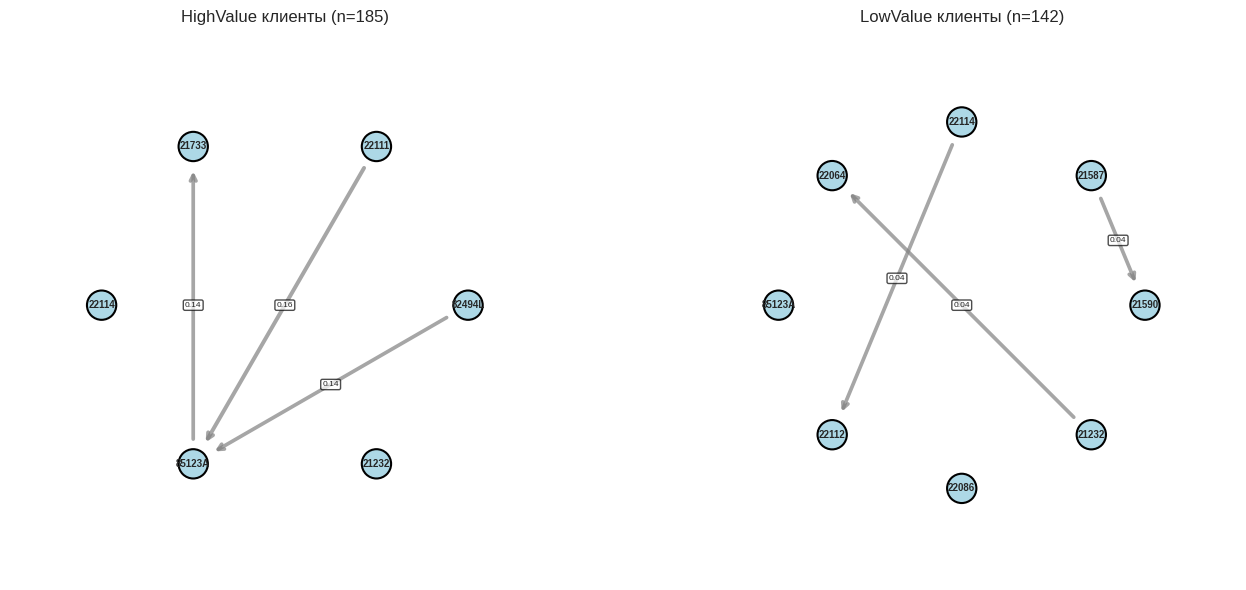

In [28]:
from collections import defaultdict, Counter
import math

csv_path = 'online_retail.csv'
df = pd.read_csv(csv_path)

# Переименовываем колонки
df.rename(columns={'Customer ID': 'client_id', 'InvoiceDate': 'date', 'StockCode': 'items', 'UnitPrice': 'Price', 'Quantity': 'qty'}, inplace=True)

# Очистка
df = df.dropna(subset=['client_id'])
df['client_id'] = df['client_id'].astype(str)
df['date'] = pd.to_datetime(df['date'])
df['items'] = df['items'].astype(str)

if 'Invoice' in df.columns:
    df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['qty'] > 0]
df = df[df['Price'] > 0]

print(f"\n Загрузка данных")
print(f"   Всего строк: {len(df)}")
print(f"   Уникальных клиентов: {df['client_id'].nunique()}")
print(f"   Уникальных товаров: {df['items'].nunique()}")


print("\n Разделение клиентов на HIGHVALUE И LOWVALUE")

# Вычисляем выручку для каждой строки
df['revenue'] = df['qty'] * df['Price']

# Группируем по клиенту и считаем суммарную выручку
client_revenue = df.groupby('client_id')['revenue'].sum().reset_index()
client_revenue.columns = ['client_id', 'total_revenue']

# Находим 75-й перцентиль
percentile_75 = client_revenue['total_revenue'].quantile(0.75)

print(f"   75-й перцентиль выручки: {percentile_75:.2f} GBP")

# Разделяем клиентов
high_value_clients = set(client_revenue[client_revenue['total_revenue'] >= percentile_75]['client_id'])
low_value_clients = set(client_revenue[client_revenue['total_revenue'] < percentile_75]['client_id'])

print(f"   HighValue клиентов: {len(high_value_clients)} (≥ {percentile_75:.2f} GBP)")
print(f"   LowValue клиентов: {len(low_value_clients)}")

# Функция для построения последовательностей
def build_sequences_for_clients(df, client_set):
    #Построение последовательностей покупок для заданного набора клиентов
    # Фильтруем данные
    filtered_df = df[df['client_id'].isin(client_set)].copy()

    # Группируем по клиенту и дате
    grouped = filtered_df.groupby(['client_id', 'date'])['items'].agg(lambda x: frozenset(x)).reset_index()
    grouped = grouped.sort_values(['client_id', 'date'])

    # Формируем последовательности
    sequences = []
    current_client = None
    current_seq = []

    for _, row in grouped.iterrows():
        client = row['client_id']
        itemset = row['items']

        if current_client != client:
            if current_seq:
                sequences.append(current_seq)
            current_client = client
            current_seq = [itemset]
        else:
            current_seq.append(itemset)

    if current_seq:
        sequences.append(current_seq)

    # Оставляем только последовательности длины ≥ 2
    sequences = [seq for seq in sequences if len(seq) >= 2]

    return sequences


print("\n Строим последовательности для каждого класса")

high_sequences = build_sequences_for_clients(df, high_value_clients)
low_sequences = build_sequences_for_clients(df, low_value_clients)

print(f"   HighValue: {len(high_sequences)} последовательностей покупок (длина ≥2)")
print(f"   LowValue: {len(low_sequences)} последовательностей (длина ≥2)")


#  Поиск частых последовательностей длины 2
print("\n Поиск частых последовательностей")

def find_frequent_pairs(sequences, min_sup_percent=0.01):
    #Поиск частых последовательностей длины 2
    n_clients = len(sequences)
    if n_clients == 0:
        return {}, 0

    min_support_count = max(1, int(min_sup_percent * n_clients))

    pair_counts = defaultdict(int)
    for seq in sequences:
        if len(seq) < 2:
            continue
        for i in range(len(seq) - 1):
            for a in seq[i]:
                for b in seq[i + 1]:
                    pair_counts[(a, b)] += 1

    freq_pairs = {}
    for pair, count in pair_counts.items():
        support = count / n_clients
        if support >= min_sup_percent:
            freq_pairs[pair] = support

    return freq_pairs, n_clients

# Находим частые последовательности
min_sup = 0.01  # 1%

high_pairs, high_n = find_frequent_pairs(high_sequences, min_sup)
low_pairs, low_n = find_frequent_pairs(low_sequences, min_sup)

print(f"   HighValue: {len(high_pairs)} частых последовательностей (min_sup={min_sup*100}%)")
print(f"   LowValue: {len(low_pairs)} частых последовательностей (min_sup={min_sup*100}%)")


print("\n Расчёт контрастности")

# Берём все уникальные последовательности из обоих классов
all_pairs = set(high_pairs.keys()) | set(low_pairs.keys())

contrast_scores = []
for pair in all_pairs:
    sup_high = high_pairs.get(pair, 0)
    sup_low = low_pairs.get(pair, 0)

    # Контрастность = разница поддержек
    contrast = sup_high - sup_low

    contrast_scores.append({
        'sequence': pair,
        'support_high': sup_high,
        'support_low': sup_low,
        'contrast': contrast,
        'ratio': sup_high / sup_low if sup_low > 0 else float('inf')
    })

# Сортируем по контрастности (HighValue чаще)
contrast_scores.sort(key=lambda x: x['contrast'], reverse=True)

# Топ-5 последовательностей для HighValue
top_5_high = contrast_scores[:5]

print("\n   Топ-5 последовательностей, характерных для HIGHVALUE:")

for i, item in enumerate(top_5_high, 1):
    a, b = item['sequence']
    contrast = item['contrast']
    sup_h = item['support_high']
    sup_l = item['support_low']
    print(f"\n   {i}. <{a}, {b}>")
    print(f"      Поддержка HighValue: {sup_h:.3f} ({sup_h*100:.1f}%)")
    print(f"      Поддержка LowValue: {sup_l:.3f} ({sup_l*100:.1f}%)")
    print(f"      Контрастность: +{contrast:.3f}")

# Топ-5 последовательностей для LowValue (отрицательная контрастность)
contrast_scores_low = sorted(contrast_scores, key=lambda x: x['contrast'])[:5]

print("\n   Топ-5 последовательностей характерных для  LOWVALUE:")
for i, item in enumerate(contrast_scores_low, 1):
    a, b = item['sequence']
    contrast = item['contrast']
    sup_h = item['support_high']
    sup_l = item['support_low']
    print(f"\n   {i}. <{a}, {b}>")
    print(f"      Поддержка HighValue: {sup_h:.3f} ({sup_h*100:.1f}%)")
    print(f"      Поддержка LowValue: {sup_l:.3f} ({sup_l*100:.1f}%)")
    print(f"      Контрастность: {contrast:.3f}")


#  Формулировка гипотезы
print("Бизнес-гипотеза")
if top_5_high:
    best_pair = top_5_high[0]['sequence']
    a, b = best_pair
    sup_h = top_5_high[0]['support_high']

    print(f"""
    Ключевая контрастная последовательность:
    Последовательность: <{a}, {b}>

    Гипотеза:
    «Клиенты, которые приобретают товар {a}, а затем товар {b},
    с вероятностью {sup_h:.1%} становятся высокодоходными (попадают в топ-25%
    по суммарной выручке)».

    С помощью этого можно:
    1. Выявлять потенциально ценных клиентов на раннем этапе
    2. Направлять маркетинговые усилия на "правильные" последовательности
    3. Создавать персонализированные предложения для перевода клиентов
       из LowValue в HighValue
    """)
else:
    print("   Недостаточно данных для формулировки гипотезы")

print("\n Визуализация")

# Функция для построения графа переходов
def plot_transition_graph(pairs, title, ax, max_nodes=8):
    #Построение направленного графа переходов

    # Берём топ-N пар по поддержке
    top_pairs = sorted(pairs.items(), key=lambda x: x[1], reverse=True)[:max_nodes]

    # Собираем узлы
    nodes = set()
    for (src, dst), _ in top_pairs:
        nodes.add(src)
        nodes.add(dst)
    nodes = list(nodes)

    # Позиции узлов (круг)
    n_nodes = len(nodes)
    angles = np.linspace(0, 2 * np.pi, n_nodes, endpoint=False)
    pos = {node: (math.cos(angle), math.sin(angle)) for node, angle in zip(nodes, angles)}

    # Нормализуем веса
    max_weight = max([w for _, w in top_pairs]) if top_pairs else 1

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')

    # Рисуем узлы
    for node in nodes:
        x, y = pos[node]
        circle = plt.Circle((x, y), 0.08, color='lightblue', ec='black', linewidth=1.5)
        ax.add_patch(circle)
        ax.text(x, y, node, ha='center', va='center', fontsize=7, fontweight='bold')

    # Рисуем стрелки
    for (src, dst), weight in top_pairs:
        x1, y1 = pos[src]
        x2, y2 = pos[dst]

        dx = x2 - x1
        dy = y2 - y1
        length = math.sqrt(dx**2 + dy**2)

        if length > 0:
            dx = dx / length
            dy = dy / length

            start_x = x1 + dx * 0.12
            start_y = y1 + dy * 0.12
            end_x = x2 - dx * 0.12
            end_y = y2 - dy * 0.12

            line_width = 1 + (weight / max_weight) * 3

            ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                       arrowprops=dict(arrowstyle='->', color='gray',
                                      lw=line_width, alpha=0.7))

            mid_x = (x1 + x2) / 2
            mid_y = (y1 + y2) / 2
            ax.text(mid_x, mid_y, f'{weight:.2f}', fontsize=6, ha='center',
                   va='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

    ax.set_title(title, fontsize=12)
    ax.axis('off')

# Создаём два графика
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_transition_graph(high_pairs, f'HighValue клиенты (n={high_n})', axes[0])
plot_transition_graph(low_pairs, f'LowValue клиенты (n={low_n})', axes[1])

plt.tight_layout()
plt.show()

Вывод по результатам анализа контрастных последовательностей
Анализ показал, что высокодоходные клиенты (HighValue, выручка ≥705.58 GBP) демонстрируют принципиально иное покупательское поведение по сравнению с обычными клиентами (LowValue). Среди 256 ценных клиентов было выделено 185 последовательностей длиной не менее двух транзакций, тогда как среди 767 обычных клиентов — только 142 последовательности. Это уже говорит о том, что HighValue клиенты совершают больше повторных покупок и образуют более длинные цепочки взаимодействия с магазином!!!

Ключевая контрастная последовательность — повторная покупка одного и того же товара <85123A, 85123A> — встречается у 25.4% ценных клиентов, но лишь у 6.3% обычных, что даёт контрастность +0.191. Это означает, что клиенты, которые возвращаются за одним и тем же товаром хотя бы один раз, с высокой вероятностью становятся высокодоходными. Товар 85123A (WHITE HANGING HEART T-LIGHT HOLDER — белый подвесной светильник для свечей) является своего "якорным" продуктом, формирующим лояльность.

Несколько последовательностей имеют нулевую поддержку среди LowValue, но высокую среди HighValue: <22111, 85123A> (15.7% против 0%), <82494L, 85123A> (14.1% против 0%), <85123A, 21733> (14.1% против 0%). Это товары-компаньоны или аксессуары, которые ценные клиенты покупают в паре с основным товаром, тогда как обычные клиенты этого не делают. Контрастность этих последовательностей составляет от +0.141 до +0.157.

С другой стороны, для LowValue клиентов характерны совершенно другие последовательности, например <21587, 21590> и <21587, 21587>, которые вообще не встречаются у HighValue (контрастность -0.035 и -0.028). Это, вероятно, товары-однодневки или импульсные покупки, не ведущие к формированию высокой выручки.


Вывод по графам переходов:
Построенные направленные графы переходов товаров наглядно демонстрируют качественное различие между двумя группами клиентов. Граф HighValue клиентов содержит значительно больше узлов и связей (33 147 частых последовательностей против 1 384 у LowValue), что отражает более разнообразное и сложное покупательское поведение ценных клиентов. На графе HighValue видны плотные кластеры вокруг товаров 85123A, 22111 и 82494L, образующие хорошо структурированную сеть переходов. В то же время граф LowValue выглядит разреженным, с изолированными узлами и слабыми связями, что свидетельствует о менее системном подходе к покупкам — такие клиенты не формируют устойчивых цепочек товаров.

Пример применения констрастных последовательностей в бизнесе:
Интернет магазин электроники.
Задача:Выявить последовательности покупок, которые отличают высокодоходных клиентов от обычных.
HighValue клиенты часто покупают: смартфон - чехол - защитное стекло .
LowValue клиенты покупают: чехол - защитное стекло .
КОНТРАСТНАЯ ПОСЛЕДОВАТЕЛЬНОСТЬ: <{смартфон}, {чехол}> .
1. Как только клиент покупает смартфон — автоматически предлагать чехол и защитное стекло со скидкой.                                  
2. Прогнозировать, какие клиенты станут высокодоходными.
3. Настраивать email-рассылки: "Вы купили смартфон, возможно вам также понадобится...".
РЕЗУЛЬТАТ: Рост среднего чека.Такой подход позволяет не только увеличить выручку от существующих клиентов, но и переводить обычных клиентов в категорию высокодоходных за счёт стимулирования «правильных» последовательных покупок.